<a href="https://colab.research.google.com/github/arthur-cristo/insta-scrap/blob/main/insta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests beautifulsoup4 pandas -q

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import re
from datetime import datetime
import time
import random
import requests
import json
import pandas as pd
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os

In [ ]:
arrobas = [
'belezaexteriorloja',
'lojasquebeleza',
'belamaquiagemstore',
'horadabelezacosmeticos',
'veneza_distribuidora',
'facedoctor_oficial',
'missgold7',
'lamassima',
'dm.executive',
'pizzariasalvadordelivery',
'bigdeliverybr',
'saladasalvadordelivery',
'restaurantediliana',
'takeaway.rest',
'restaurantetijuanaoficial',
'sexta.baiana']

for arroba in arrobas:
  print(f'curl "https://www.instagram.com/api/v1/users/web_profile_info/?username={arroba}" -H "x-ig-app-id: 936619743392459" -H "User-Agent: Mozilla/5.0" > {arroba}.json')

curl "https://www.instagram.com/api/v1/users/web_profile_info/?username=belezaexteriorloja" -H "x-ig-app-id: 936619743392459" -H "User-Agent: Mozilla/5.0" > belezaexteriorloja.json
curl "https://www.instagram.com/api/v1/users/web_profile_info/?username=lojasquebeleza" -H "x-ig-app-id: 936619743392459" -H "User-Agent: Mozilla/5.0" > lojasquebeleza.json
curl "https://www.instagram.com/api/v1/users/web_profile_info/?username=belamaquiagemstore" -H "x-ig-app-id: 936619743392459" -H "User-Agent: Mozilla/5.0" > belamaquiagemstore.json
curl "https://www.instagram.com/api/v1/users/web_profile_info/?username=horadabelezacosmeticos" -H "x-ig-app-id: 936619743392459" -H "User-Agent: Mozilla/5.0" > horadabelezacosmeticos.json
curl "https://www.instagram.com/api/v1/users/web_profile_info/?username=veneza_distribuidora" -H "x-ig-app-id: 936619743392459" -H "User-Agent: Mozilla/5.0" > veneza_distribuidora.json
curl "https://www.instagram.com/api/v1/users/web_profile_info/?username=facedoctor_oficial"

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving belamaquiagemstore.json to belamaquiagemstore.json
Saving belezaexteriorloja.json to belezaexteriorloja.json
Saving bigdeliverybr.json to bigdeliverybr.json
Saving dm.executive.json to dm.executive.json
Saving facedoctor_oficial.json to facedoctor_oficial.json
Saving horadabelezacosmeticos.json to horadabelezacosmeticos.json
Saving lamassima.json to lamassima.json
Saving lojasquebeleza.json to lojasquebeleza.json
Saving missgold7.json to missgold7.json
Saving pizzariasalvadordelivery.json to pizzariasalvadordelivery.json
Saving restaurantediliana.json to restaurantediliana.json
Saving restaurantetijuanaoficial.json to restaurantetijuanaoficial.json
Saving saladasalvadordelivery.json to saladasalvadordelivery.json
Saving takeaway.rest.json to takeaway.rest.json
Saving veneza_distribuidora.json to veneza_distribuidora.json


In [ ]:
CATEGORIES = {
    "restaurante": ["pizza", "restaurante", "burger", "food", "hamburguer", "salada", "sabor"],
    "estetica": ["beleza", "beauty", "maquiagem", "cosmeticos", "face", "skin", "unha", "nail", "lashe", "salao"],
    "moda": ["fashion", "moda", "roupa"]
}

def definir_categoria(nome_perfil, bio, username):
    texto = (nome_perfil + " " + bio + " " + username).lower()
    for cat, palavras in CATEGORIES.items():
        if any(palavra in texto for palavra in palavras):
            return cat
    return "outros"

lista_perfis = []
lista_todos_posts = []

arquivos_json = [
    'belamaquiagemstore.json', 'belezaexteriorloja.json', 'bigdeliverybr.json',
    'dm.executive.json', 'facedoctor_oficial.json', 'horadabelezacosmeticos.json',
    'lamassima.json', 'lojasquebeleza.json', 'missgold7.json',
    'pizzariasalvadordelivery.json', 'restaurantediliana.json',
    'restaurantetijuanaoficial.json', 'saladasalvadordelivery.json',
    'takeaway.rest.json', 'veneza_distribuidora.json'
]

for arquivo in arquivos_json:
    if not os.path.exists(arquivo): continue

    with open(arquivo, 'r', encoding='utf-8') as f:
        conteudo = json.load(f)
        dados = conteudo['data']['user']

    categoria = definir_categoria(dados['full_name'], dados['biography'], dados['username'])

    lista_perfis.append({
        'id': dados['id'],
        'arroba': dados['username'],
        'nome': dados['full_name'],
        'categoria': categoria,
        'seguidores': dados['edge_followed_by']['count']
    })

    posts = dados.get('edge_owner_to_timeline_media', {}).get('edges', [])

    for p in posts:
        node = p['node']

        curtidas = node.get('edge_liked_by', {}).get('count', 0)
        comentarios = node.get('edge_media_to_comment', {}).get('count', 0)

        shortcode = node.get('shortcode', '')
        url_post = f"https://www.instagram.com/p/{shortcode}/" if shortcode else ""

        lista_todos_posts.append({
            'perfil_id': dados['id'],
            'id': node['id'],
            'data': pd.to_datetime(node['taken_at_timestamp'], unit='s'),
            'views': node.get('video_view_count', 0),
            'curtidas': curtidas,
            'comentarios': comentarios,
            'tipo': 'video' if node['__typename'] == 'GraphVideo' else 'imagem',
            'url_post': url_post
        })

df_perfis = pd.DataFrame(lista_perfis)
df_posts = pd.DataFrame(lista_todos_posts)

dict_perfis = df_perfis.set_index('id')['arroba'].to_dict()
df_posts['arroba'] = df_posts['perfil_id'].map(dict_perfis)

df_posts_filtrado = df_posts[df_posts['views'] > 0].copy()

print("--- TODOS OS PERFIS ---")
display(df_perfis)
print("\n--- POSTS COM VISUALIZAÇÕES E URL ---")
display(df_posts_filtrado.head())

nome_arquivo = 'analise_instagram_filtrada.xlsx'
with pd.ExcelWriter(nome_arquivo, engine='openpyxl') as writer:
    df_perfis.to_excel(writer, sheet_name='Perfis', index=False)
    df_posts_filtrado.to_excel(writer, sheet_name='Posts', index=False)

print(f"\nArquivo '{nome_arquivo}' gerado com sucesso!")
print(f"Total de posts capturados: {len(df_posts)} > {len(df_posts_filtrado)}")

--- TODOS OS PERFIS ---


,id,arroba,nome,categoria,seguidores
0,7101206598,belamaquiagemstore,"Loja Bela Maquiagem | Salvador, BA",estetica,11868
1,6415259341,belezaexteriorloja,Loja Beleza Exterior,estetica,91874
2,5745836343,bigdeliverybr,Açougue BigDelivery,restaurante,35516
3,502302013,dm.executive,Moda Delivery Salvador | Roupa,moda,6572
4,27793704123,facedoctor_oficial,Face Doctor Oficial,estetica,27895
5,5949768018,horadabelezacosmeticos,Hora da Beleza | A sua loja de Cosméticos,estetica,9496
6,419221812,lamassima,La Mássima | Delivery - Salvador,restaurante,7819
7,9257627205,lojasquebeleza,Loja Que Beleza! - Salvador/BA,estetica,8543
8,8181417873,missgold7,"MISS GOLD | Unhas, Cílios & Cosméticos ✨",estetica,40335
9,2095921001,pizzariasalvadordelivery,Pizzaria Salvador,restaurante,7808



--- POSTS COM VISUALIZAÇÕES E URL ---


,perfil_id,id,data,views,curtidas,comentarios,tipo,url_post,arroba
11,7101206598,3886023455032812610,2026-04-29 13:44:36,176,24,3,video,https://www.instagram.com/p/DXt7b5KESRC/,belamaquiagemstore
15,6415259341,3854382188518076867,2026-03-16 21:57:24,33662,1094,231,video,https://www.instagram.com/p/DV9hC3XNnHD/,belezaexteriorloja
17,6415259341,3836779659703175541,2026-02-20 15:04:24,8370,826,36,video,https://www.instagram.com/p/DU--sW6DUl1/,belezaexteriorloja
18,6415259341,3818915444975311007,2026-01-26 23:30:38,8167,706,40,video,https://www.instagram.com/p/DT_g10dAZif/,belezaexteriorloja
21,6415259341,3791083080396965709,2025-12-19 13:53:13,23094,3430,92,video,https://www.instagram.com/p/DScofnBDgdN/,belezaexteriorloja



Arquivo 'analise_instagram_filtrada.xlsx' gerado com sucesso!
Total de posts capturados: 180 > 76


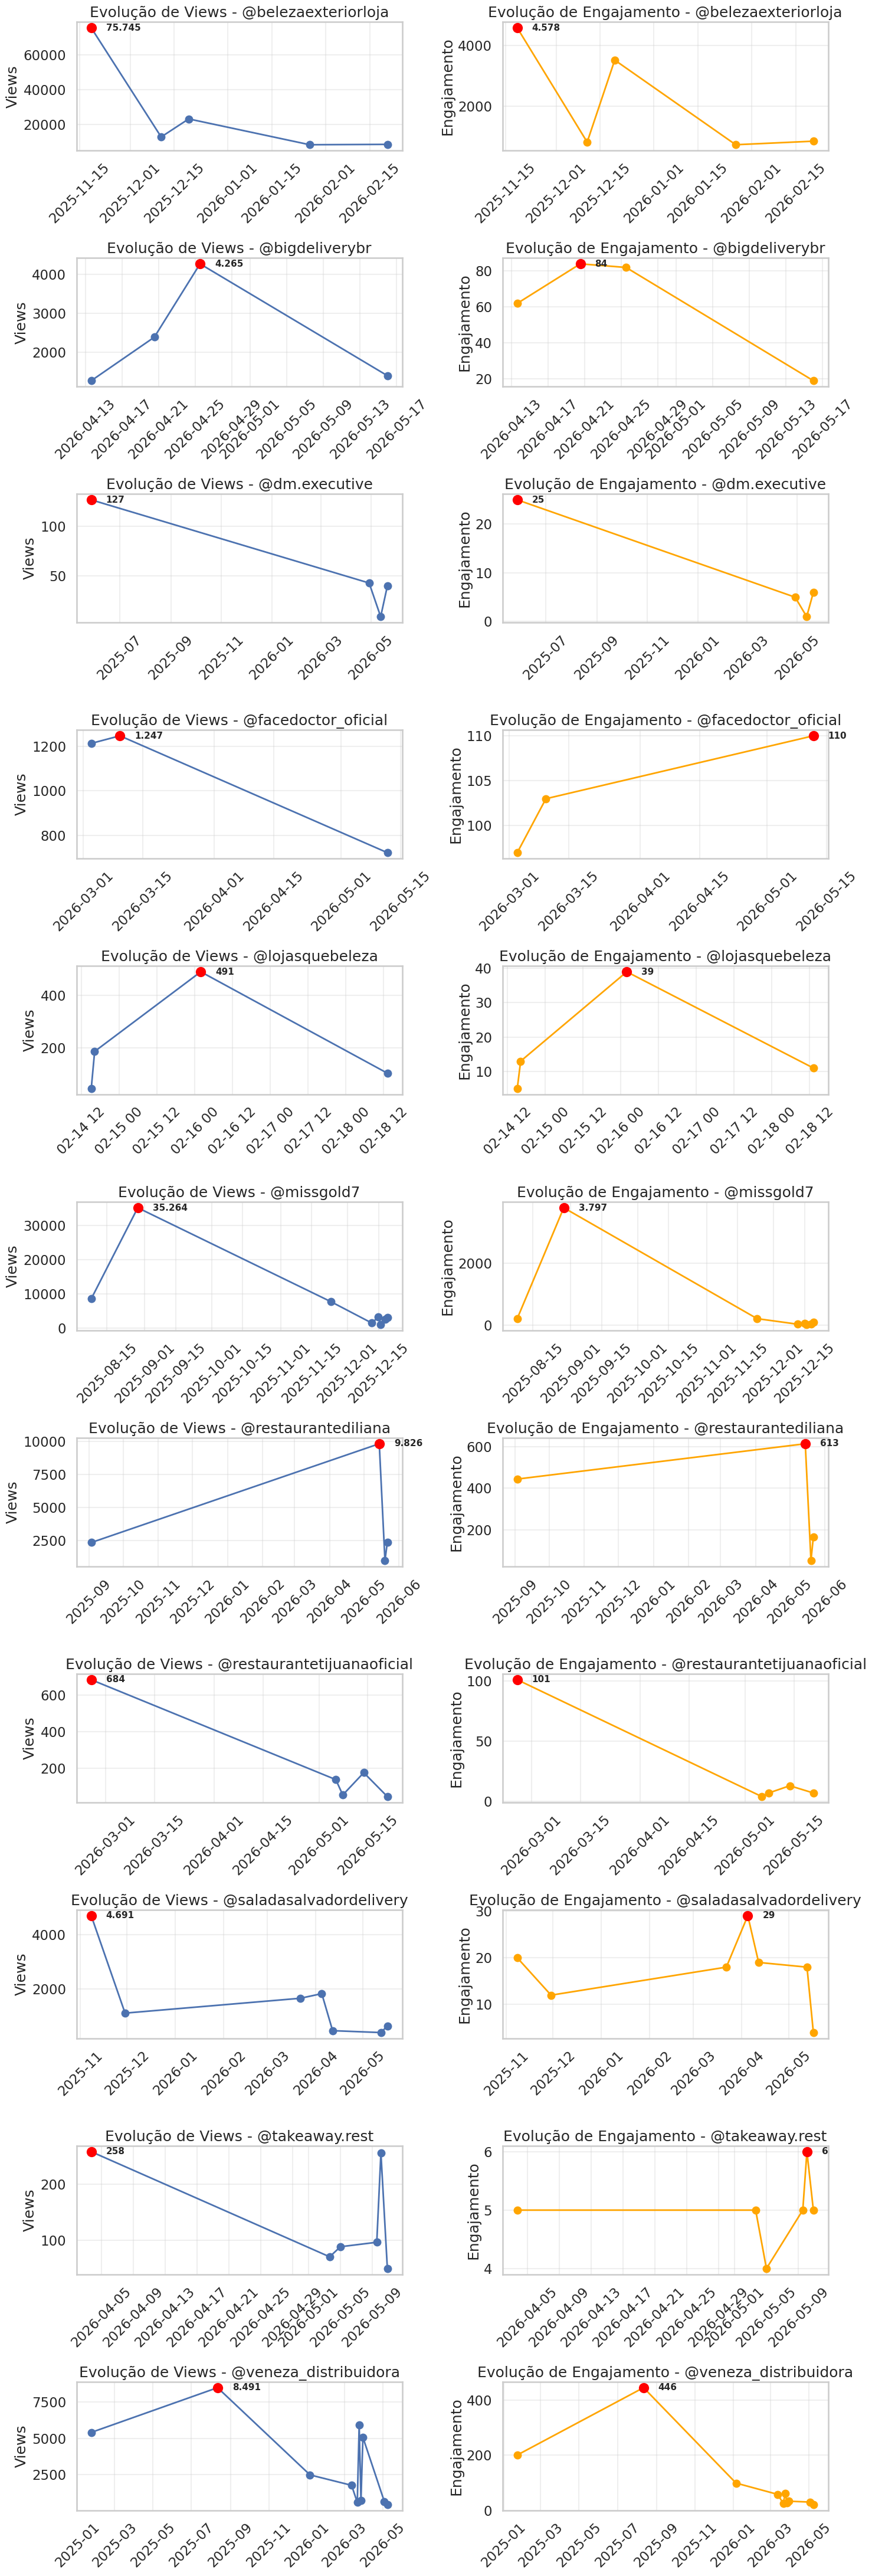


 📊 RELATÓRIO FINAL DE PERFORMANCE

🌍 VISÃO GERAL (TODAS AS CONTAS SOMADAS):
🕒 Melhor Horário - Views: Manhã | Engajamento: Tarde
📱 Melhor Formato - Views: video | Engajamento: video
------------------------------------------------------------

CONTA: @belezaexteriorloja - estetica
🔗 Post + Views: https://www.instagram.com/p/DRM9XpcDTn-/
🔗 Post + Engajamento: https://www.instagram.com/p/DRM9XpcDTn-/
🕒 Melhor horário:
   - Views: Tarde | Engajamento: Tarde
📱 Melhor formato (Imagem/Vídeo):
   - Views: video | Engajamento: video
............................................................

CONTA: @bigdeliverybr - restaurante
🔗 Post + Views: https://www.instagram.com/p/DXje3pEiQWI/
🔗 Post + Engajamento: https://www.instagram.com/p/DXWmxmBjbDR/
🕒 Melhor horário:
   - Views: Tarde | Engajamento: Tarde
📱 Melhor formato (Imagem/Vídeo):
   - Views: video | Engajamento: video
............................................................

CONTA: @dm.executive - moda
🔗 Post + Views: https://www.ins

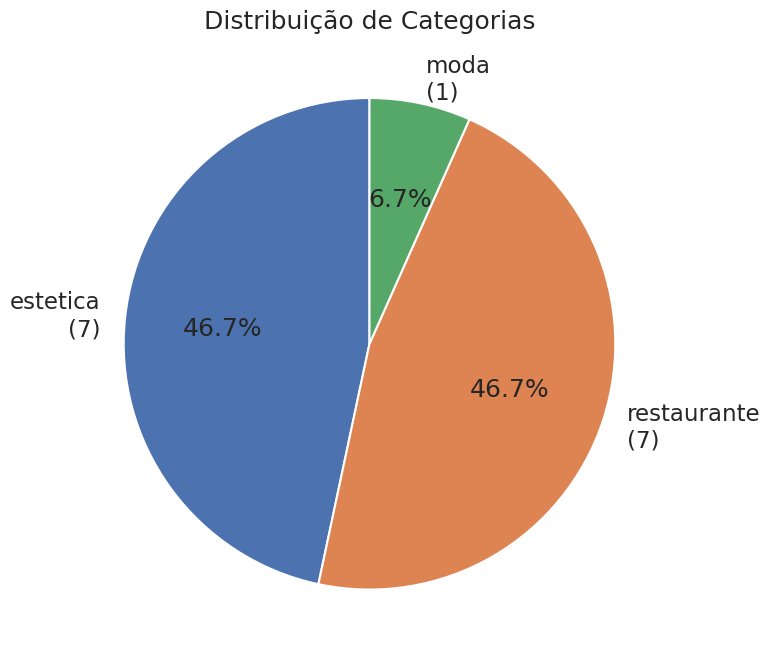

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def classificar_periodo(hora):
    if 6 <= hora < 12:
        return 'Manhã'
    elif 12 <= hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df_posts = pd.read_excel(
    "analise_instagram_filtrada.xlsx",
    sheet_name="Posts"
)

df_posts["data"] = pd.to_datetime(df_posts["data"])
df_posts["periodo"] = df_posts["data"].dt.hour.apply(classificar_periodo)

df_posts = df_posts[df_posts["views"] > 0].copy()

df_posts["engajamento"] = (
    df_posts["curtidas"].fillna(0)
    + df_posts["comentarios"].fillna(0)
)

grupos_validos = []

for arroba, grupo in df_posts.groupby("arroba"):
    grupo = grupo.sort_values("data").copy()
    grupo = grupo.iloc[:-1]

    if len(grupo) >= 2:
        grupos_validos.append((arroba, grupo))
    else:
        continue

N = len(grupos_validos)
fig, axes = plt.subplots(nrows=N, ncols=2, figsize=(15, 4 * N))

if N == 1:
    axes = [axes]

resumo_final = []

for i, (arroba, grupo) in enumerate(grupos_validos):
    ax_views = axes[i][0]
    ax_eng = axes[i][1]

    ax_views.plot(grupo["data"], grupo["views"], marker="o", linewidth=2)
    ax_views.set_title(f"Evolução de Views - @{arroba}")
    ax_views.set_ylabel("Views")
    ax_views.tick_params(axis='x', rotation=45)

    pico = grupo.loc[grupo["views"].idxmax()]
    ax_views.scatter(pico["data"], pico["views"], s=120, color="red", zorder=5)
    ax_views.annotate(
        f'{int(pico["views"]):,}'.replace(",", "."),
        xy=(pico["data"], pico["views"]),
        xytext=(18, 0), textcoords="offset points",
        fontsize=11, fontweight="bold", va="center", ha="left"
    )
    ax_views.grid(alpha=0.3)

    ax_eng.plot(grupo["data"], grupo["engajamento"], marker="o", linewidth=2, color="orange")
    ax_eng.set_title(f"Evolução de Engajamento - @{arroba}")
    ax_eng.set_ylabel("Engajamento")
    ax_eng.tick_params(axis='x', rotation=45)

    pico_eng = grupo.loc[grupo["engajamento"].idxmax()]
    ax_eng.scatter(pico_eng["data"], pico_eng["engajamento"], s=120, color="red", zorder=5)
    ax_eng.annotate(
        f'{int(pico_eng["engajamento"]):,}'.replace(",", "."),
        xy=(pico_eng["data"], pico_eng["engajamento"]),
        xytext=(18, 0), textcoords="offset points",
        fontsize=11, fontweight="bold", va="center", ha="left"
    )
    ax_eng.grid(alpha=0.3)

    url_mais_views = pico.get("url_post", "URL não disponível")
    url_mais_engajamento = pico_eng.get("url_post", "URL não disponível")

    media_periodo = grupo.groupby("periodo")[["views", "engajamento"]].mean()
    melhor_periodo_views = media_periodo["views"].idxmax() if not media_periodo.empty else "N/A"
    melhor_periodo_eng = media_periodo["engajamento"].idxmax() if not media_periodo.empty else "N/A"

    media_tipo = grupo.groupby("tipo")[["views", "engajamento"]].mean()
    melhor_tipo_views = media_tipo["views"].idxmax() if not media_tipo.empty else "N/A"
    melhor_tipo_eng = media_tipo["engajamento"].idxmax() if not media_tipo.empty else "N/A"

    mapa_categoria = (
      df_perfis
      .groupby("arroba")["categoria"]
      .first()
      .to_dict()
    )

    resumo_final.append({
        "arroba": arroba,
        "categoria": mapa_categoria.get(arroba, "Sem categoria"),
        "url_views": url_mais_views,
        "url_eng": url_mais_engajamento,
        "periodo_views": melhor_periodo_views,
        "periodo_eng": melhor_periodo_eng,
        "tipo_views": melhor_tipo_views,
        "tipo_eng": melhor_tipo_eng
    })

plt.tight_layout()
plt.show()

media_periodo_global = df_posts.groupby("periodo")[["views", "engajamento"]].mean()
melhor_periodo_views_global = media_periodo_global["views"].idxmax()
melhor_periodo_eng_global = media_periodo_global["engajamento"].idxmax()

media_tipo_global = df_posts.groupby("tipo")[["views", "engajamento"]].mean()
melhor_tipo_views_global = media_tipo_global["views"].idxmax()
melhor_tipo_eng_global = media_tipo_global["engajamento"].idxmax()

print("\n" + "="*60)
print(" 📊 RELATÓRIO FINAL DE PERFORMANCE")
print("="*60)

print("\n🌍 VISÃO GERAL (TODAS AS CONTAS SOMADAS):")
print(f"🕒 Melhor Horário - Views: {melhor_periodo_views_global} | Engajamento: {melhor_periodo_eng_global}")
print(f"📱 Melhor Formato - Views: {melhor_tipo_views_global} | Engajamento: {melhor_tipo_eng_global}")
print("-" * 60)

for r in resumo_final:
    print(f"\nCONTA: @{r['arroba']} - {r['categoria']}")
    print(f"🔗 Post + Views: {r['url_views']}")
    print(f"🔗 Post + Engajamento: {r['url_eng']}")
    print(f"🕒 Melhor horário:")
    print(f"   - Views: {r['periodo_views']} | Engajamento: {r['periodo_eng']}")
    print(f"📱 Melhor formato (Imagem/Vídeo):")
    print(f"   - Views: {r['tipo_views']} | Engajamento: {r['tipo_eng']}")
    print("." * 60)

print("\n🏷️ RESUMO POR CATEGORIA")
print("=" * 60)

df_posts["categoria"] = df_posts["arroba"].map(mapa_categoria)

for categoria, grupo_cat in df_posts.groupby("categoria"):

    media_views = grupo_cat["views"].mean()
    media_eng = grupo_cat["engajamento"].mean()

    media_periodo = grupo_cat.groupby("periodo")[["views", "engajamento"]].mean()

    melhor_periodo_views = (
        media_periodo["views"].idxmax()
        if not media_periodo.empty else "N/A"
    )

    melhor_periodo_eng = (
        media_periodo["engajamento"].idxmax()
        if not media_periodo.empty else "N/A"
    )

    media_tipo = grupo_cat.groupby("tipo")[["views", "engajamento"]].mean()

    melhor_tipo_views = (
        media_tipo["views"].idxmax()
        if not media_tipo.empty else "N/A"
    )

    melhor_tipo_eng = (
        media_tipo["engajamento"].idxmax()
        if not media_tipo.empty else "N/A"
    )

    melhor_post_views = grupo_cat.loc[grupo_cat["views"].idxmax()]
    melhor_post_eng = grupo_cat.loc[grupo_cat["engajamento"].idxmax()]

    print(f"\n📂 CATEGORIA: {categoria.upper()}")

    print(
        f"📈 Média Views: "
        f"{int(media_views):,}".replace(",", ".")
    )

    print(
        f"💬 Média Engajamento: "
        f"{int(media_eng):,}".replace(",", ".")
    )

    print(
        f"🕒 Melhor horário:"
        f"\n   - Views: {melhor_periodo_views}"
        f"\n   - Engajamento: {melhor_periodo_eng}"
    )

    print(
        f"📱 Melhor formato:"
        f"\n   - Views: {melhor_tipo_views}"
        f"\n   - Engajamento: {melhor_tipo_eng}"
    )

    views_formatadas = (
        f"{int(melhor_post_views['views']):,}"
        .replace(",", ".")
    )

    print(
        f"🏆 Melhor post Views:"
        f"\n   - @{melhor_post_views['arroba']}"
        f"\n   - {views_formatadas} views"
        f"\n   - URL: {melhor_post_views.get('url_post', 'URL não disponível')}"
    )

    eng_formatado = (
        f"{int(melhor_post_eng['engajamento']):,}"
        .replace(",", ".")
    )

    print(
        f"🏆 Melhor post Engajamento:"
        f"\n   - @{melhor_post_eng['arroba']}"
        f"\n   - {eng_formatado} engajamento"
        f"\n   - URL: {melhor_post_eng.get('url_post', 'URL não disponível')}"
    )

    print("." * 60)


plt.figure(figsize=(8, 8))

contagem_categorias = (
    df_perfis["categoria"]
    .value_counts()
)

labels = [
    f"{categoria}\n({quantidade})"
    for categoria, quantidade in zip(
        contagem_categorias.index,
        contagem_categorias.values
    )
]

plt.pie(
    contagem_categorias.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribuição de Categorias")

plt.tight_layout()
plt.show()